In [ ]:
import sys
from matplotlib import pyplot
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.layers import Conv2D, Flatten, Dense
from keras.models import Sequential
from keras.optimizers import SGD

In [2]:
## carregando conjunto dos dados de treino e teste
def load_dataset():
  (trainX,trainY),(testX,testY) = cifar10.load_data()
  trainY = to_categorical(trainY)
  testY = to_categorical(testY)
  return trainX, trainY, testX, testY

# normalizando as imagens
def prep_pixels(train,test):
  train_norm = train.astype('float32')
  test_norm = test.astype('float32')
  train_norm = train_norm/255.0
  test_norm = test_norm/255.0
  return train_norm, test_norm

c:\Users\Visitante\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


> 67.190


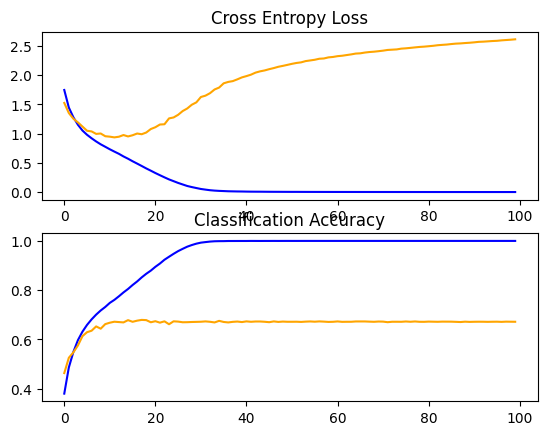

In [3]:
from keras.src.layers import MaxPooling2D
# definindo o modelo cnn
def define_model():
  model = Sequential()
  model.add(Conv2D(32,(3,3), activation='relu', kernel_initializer = 'he_uniform', padding = "same", input_shape = (32, 32, 3) ))
  model.add(Conv2D(32,(3,3), activation='relu', kernel_initializer = 'he_uniform', padding = "same"))
  model.add(MaxPooling2D((2,2)))
  model.add(Flatten())
  model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
  model.add(Dense(10, activation='softmax'))
  opt = SGD(learning_rate=0.001, momentum=0.9)
  model.compile(optimizer = opt, loss= 'categorical_crossentropy', metrics = ['accuracy'])
  return model
# plot das curvas diagnosticas de aprendizado
def summarize_diagnostics(history):
  ## plot loss
  pyplot.subplot(211)
  pyplot.title('Cross Entropy Loss')
  pyplot.plot(history.history['loss'], color = 'blue', label = 'train')
  pyplot.plot(history.history['val_loss'], color = 'orange', label = 'test')
  ## plot acuracia
  pyplot.subplot(212)
  pyplot.title('Classification Accuracy')
  pyplot.plot(history.history['accuracy'], color = 'blue', label = 'train')
  pyplot.plot(history.history['val_accuracy'], color = 'orange', label = 'test')
  ## save plot to file
  #filename = sys.argv[0].split('/')[-1]
  #pyplot.savefig(filename + '_plot.png')
  #pyplot.close()
  pyplot.show()
def run_test_harness():
  trainX, trainY, testX, testY = load_dataset()
  trainX, testX = prep_pixels(trainX, testX)
  model = define_model()
  history = model.fit(trainX, trainY, epochs = 100, batch_size = 64, validation_data = (testX, testY), verbose = 0)
  _, acc = model.evaluate(testX, testY, verbose = 0)
  print('> %.3f' % (acc*100.0))
  summarize_diagnostics(history)

run_test_harness()